# Universo 25 — Simulação Baseada em Agentes

Recriação computacional do experimento de John B. Calhoun (1968) utilizando
Modelagem Baseada em Agentes (ABM) com o framework **Mesa**.

O modelo implementa os parâmetros definidos em `projeto/params.md` e reproduz
as quatro fases do experimento original:

1. **Ajuste** (Dia 0–104) — Os primeiros agentes se estabelecem e começam a se reproduzir
2. **Exploração** (Dia 105–314) — Crescimento populacional exponencial (~620 ao fim)
3. **Estagnação / Ralo Comportamental** (Dia 315–559) — Pico de ~2.200, colapso social
4. **Extinção / Os Lindos** (Dia 560–1588) — Último nascimento no dia 600, declínio gradual até extinção


In [2]:
from universo25_model import (
    Universe25Model, MouseAgent,
    GRID_WIDTH, GRID_HEIGHT, STEPS,
    plot_grid, plot_metrics, get_agent_color
)
import matplotlib.pyplot as plt
import numpy as np

print(f"Grid: {GRID_WIDTH}x{GRID_HEIGHT}")
print(f"Steps: {STEPS}")
print("Modelo carregado com sucesso!")


Grid: 50x50
Steps: 1588
Modelo carregado com sucesso!


In [3]:
%%time
model = Universe25Model(rng=42)

for i in range(STEPS):
    model.step()

data = model.datacollector.get_model_vars_dataframe()
pop = data['Population']
print(f"População final: {pop.iloc[-1]:.0f}")
print(f"Pico populacional: {pop.max():.0f} no passo {pop.idxmax()}")
print(f"Estresse médio final: {data['Mean Stress'].iloc[-1]:.3f}")
print(f"Estresse da colônia final: {data['Colony Stress'].iloc[-1]:.3f}")
print(f"Total de nascimentos: {data['Total Births'].iloc[-1]:.0f}")
print(f"Total de mortes: {data['Total Deaths'].iloc[-1]:.0f}")
print(f"Agentes BEAUTIFUL: {data['BEAUTIFUL Count'].iloc[-1]:.0f}")


População final: 0
Pico populacional: 3442 no passo 301
Estresse médio final: 0.000
Estresse da colônia final: 0.000
Total de nascimentos: 8433
Total de mortes: 8441
Agentes BEAUTIFUL: 0
CPU times: user 1min 17s, sys: 654 ms, total: 1min 17s
Wall time: 1min 16s


## Grade de Agentes (Passo Final)

Visualização espacial dos agentes no grid. Cada ponto representa um agente,
colorido conforme seu tipo:

- 🔵 Azul escuro: Macho ALPHA
- 🔵 Azul claro: Macho BETA
- 🷮 Rosa: Fêmea MATERNAL
- 🷮 Rosa escuro: Fêmea grávida
- 🟡 Amarelo: Filhote
- ⚪ Cinza: BEAUTIFUL (Lindo)
- 🟤 Marrom: Morto

O fundo bege representa células vazias, verde são ninhos e laranja estações de comida.


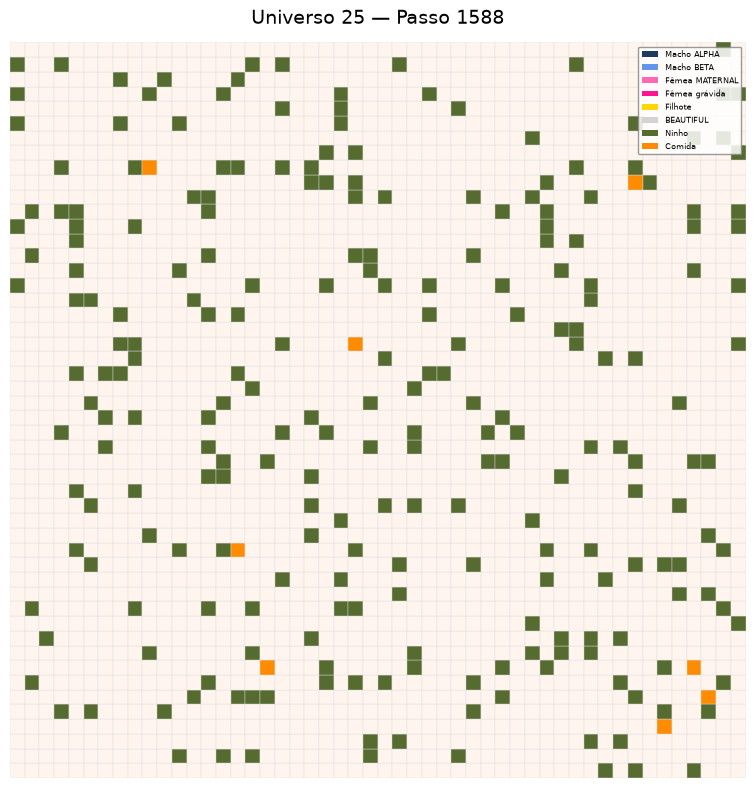

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_grid(model, ax=ax)
plt.suptitle(f'Universo 25 — Passo {STEPS}', fontsize=14)
plt.tight_layout()
plt.show()


## Métricas da Simulação

Os gráficos abaixo mostram a evolução temporal da simulação, incluindo
a comparação com a curva alvo do experimento original de Calhoun.


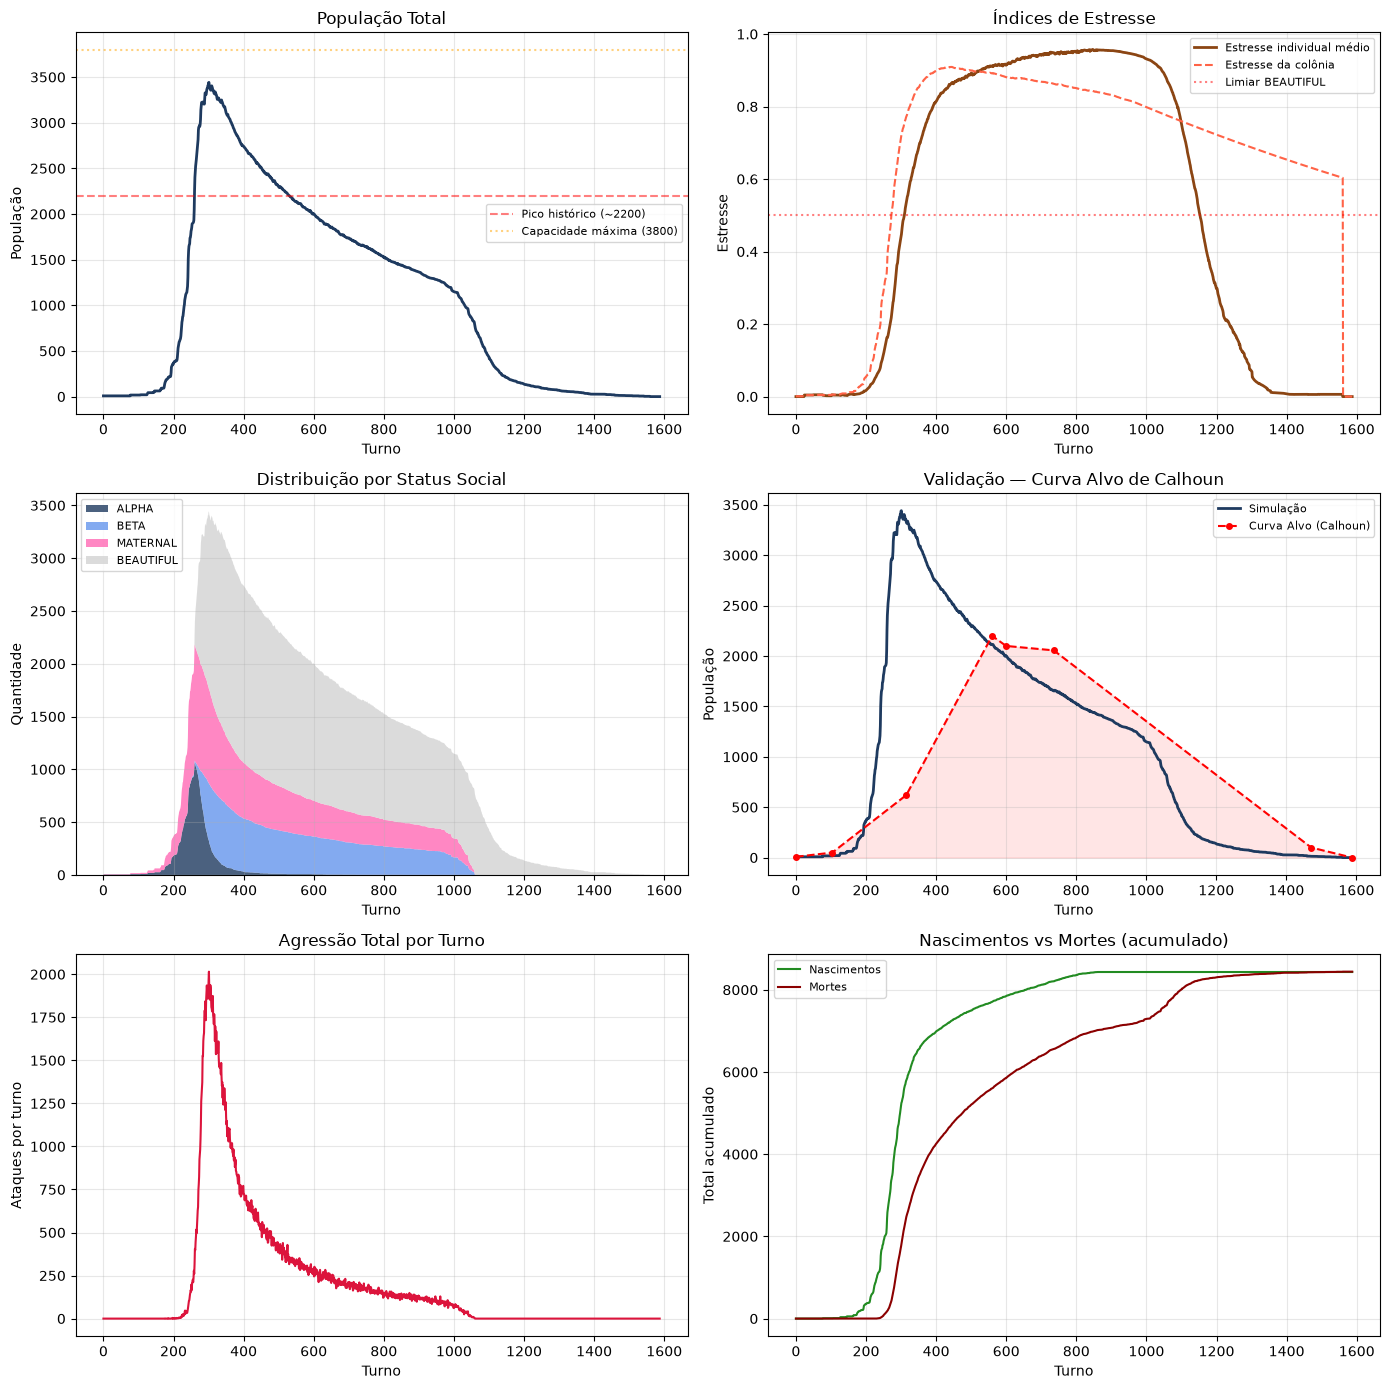

In [5]:
fig = plot_metrics(model)
plt.show()


## Resumo das Fases

Abaixo, a população em pontos-chave da simulação comparada com o experimento original.


In [6]:
print("Fase               | Dia | População | Alvo Calhoun |")
print("-" * 65)
checkpoints = [
    (0,    "Início",        8),
    (104,  "Fim Fase A",    50),
    (315,  "Fim Fase B",    620),
    (560,  "Pico",          2200),
    (600,  "Último nasc.",  2100),
    (736,  "Declínio",      2056),
    (1471, "Quase ext.",    100),
    (1588, "Extinção",      0),
]
for d, name, target in checkpoints:
    if d < len(pop):
        sim = pop.iloc[d]
        if target > 0:
            pct = sim / target * 100
            match = "✓" if abs(pct - 100) < 25 else "△" if abs(pct - 100) < 50 else "✗"
            print(f"{name:16s} | {d:4d} | {sim:6.0f}     | {target:4d}      | {pct:3.0f}% {match}")
        else:
            print(f"{name:16s} | {d:4d} | {sim:6.0f}     | {target:4d}      | —")

print()
print(f"Agentes BEAUTIFUL no final: {data['BEAUTIFUL Count'].iloc[-1]:.0f}")
print(f"Estresse da colônia no final: {data['Colony Stress'].iloc[-1]:.3f}")


Fase               | Dia | População | Alvo Calhoun |
-----------------------------------------------------------------
Início           |    0 |      8     |    8      | 100% ✓
Fim Fase A       |  104 |     17     |   50      |  34% ✗
Fim Fase B       |  315 |   3330     |  620      | 537% ✗
Pico             |  560 |   2113     | 2200      |  96% ✓
Último nasc.     |  600 |   2000     | 2100      |  95% ✓
Declínio         |  736 |   1654     | 2056      |  80% ✓
Quase ext.       | 1471 |     13     |  100      |  13% ✗

Agentes BEAUTIFUL no final: 0
Estresse da colônia no final: 0.000


## Comparacao: Enriquecimento Ambiental

Rodando a simulacao com e sem `ENVIRONMENTAL_ENRICHMENT` para comparar o impacto
do estimulo mental na prevencao do surgimento d'Os Lindos e no colapso populacional.


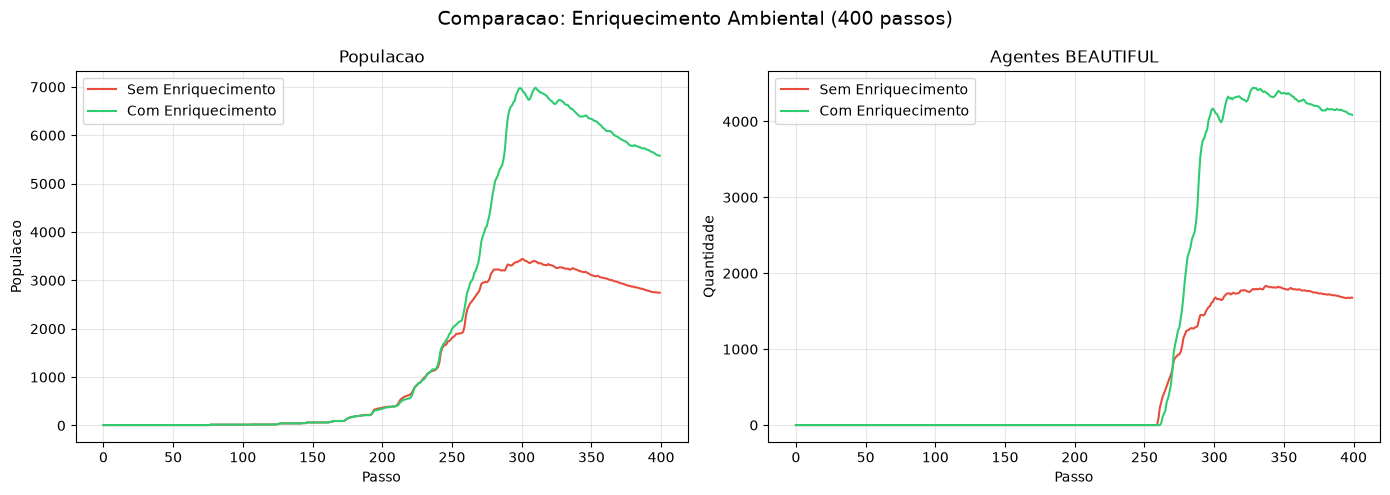

--- Sem Enriquecimento ---
  Pop final: 2744
  BEAUTIFUL final: 1678
  Estresse final: 0.813
--- Com Enriquecimento ---
  Pop final: 5578
  BEAUTIFUL final: 4087
  Estresse final: 0.675


In [7]:
def run_comparison(steps=400):
    models = {
        'Sem Enriquecimento': Universe25Model(rng=42, environmental_enrichment=False),
        'Com Enriquecimento': Universe25Model(rng=42, environmental_enrichment=True),
    }
    results = {}
    for label, m in models.items():
        for _ in range(steps):
            m.step()
        d = m.datacollector.get_model_vars_dataframe()
        results[label] = d
    return results

results = run_comparison(400)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'Sem Enriquecimento': '#E74C3C', 'Com Enriquecimento': '#2ECC71'}
for label, d in results.items():
    axes[0].plot(d['Population'], color=colors[label], label=label, linewidth=1.5)
    axes[1].plot(d['BEAUTIFUL Count'], color=colors[label], label=label, linewidth=1.5)

axes[0].set_title('Populacao')
axes[0].set_xlabel('Passo')
axes[0].set_ylabel('Populacao')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Agentes BEAUTIFUL')
axes[1].set_xlabel('Passo')
axes[1].set_ylabel('Quantidade')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Comparacao: Enriquecimento Ambiental (400 passos)', fontsize=14)
plt.tight_layout()
plt.show()

for label, d in results.items():
    print(f'--- {label} ---')
    print(f'  Pop final: {d["Population"].iloc[-1]:.0f}')
    print(f'  BEAUTIFUL final: {d["BEAUTIFUL Count"].iloc[-1]:.0f}')
    print(f'  Estresse final: {d["Mean Stress"].iloc[-1]:.3f}')
